In [38]:
from __future__ import print_function

import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.activations import relu
from tensorflow.keras.regularizers import l2
from tensorflow.keras.constraints import max_norm
from tensorflow.keras import backend as K
from tensorflow.keras.datasets import cifar100, cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

print("Packages Loaded")

Packages Loaded


In [39]:
# Now import Cifar-10 data and process it.
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [40]:
# Now import Cifar-100 data and process it.
(x_train_100, y_train_100), (x_test_100, y_test_100) = cifar100.load_data()
x_train_100 = x_train_100.astype('float32')
x_test_100 = x_test_100.astype('float32')
x_train_100 /= 255
x_test_100 /= 255

y_train_100 = tf.keras.utils.to_categorical(y_train_100, 100)
y_test_100 = tf.keras.utils.to_categorical(y_test_100, 100)

Train on 50000 samples, validate on 10000 samples
Epoch 1/20
50000/50000 [==============================] - 4s 71us/step - loss: 1.8764 - acc: 0.3139 - val_loss: 1.7159 - val_acc: 0.3774
Epoch 2/20
50000/50000 [==============================] - 3s 54us/step - loss: 1.6817 - acc: 0.3952 - val_loss: 1.6281 - val_acc: 0.4172
Epoch 3/20
50000/50000 [==============================] - 3s 58us/step - loss: 1.5985 - acc: 0.4273 - val_loss: 1.6773 - val_acc: 0.4060
Epoch 4/20
50000/50000 [==============================] - 3s 55us/step - loss: 1.5481 - acc: 0.4447 - val_loss: 1.6323 - val_acc: 0.4176
Epoch 5/20
50000/50000 [==============================] - 3s 55us/step - loss: 1.5181 - acc: 0.4551 - val_loss: 1.6112 - val_acc: 0.4194
Epoch 6/20
50000/50000 [==============================] - 3s 55us/step - loss: 1.4843 - acc: 0.4701 - val_loss: 1.5149 - val_acc: 0.4620
Epoch 7/20
50000/50000 [==============================] - 3s 55us/step - loss: 1.4645 - acc: 0.4765 - val_loss: 1.4995 - val_acc

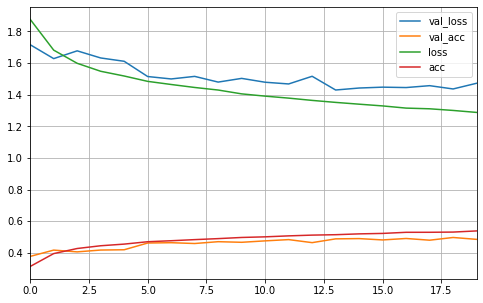

CPU times: user 1min 32s, sys: 12.1 s, total: 1min 44s
Wall time: 59.2 s


In [25]:
%%time
# Our baseline model for this lab.
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(3072,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.compile(loss='categorical_crossentropy',
              optimizer=SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True),
              metrics=['accuracy'])

# Notice that you can reshape the data for an MLP inside the fit call without changing it globally!
history = model.fit(x_train.reshape(50000, 3072), y_train, epochs=20, batch_size=64, validation_data=(x_test.reshape(10000, 3072), y_test))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Train on 50000 samples, validate on 10000 samples
Epoch 1/20
50000/50000 [==============================] - 4s 75us/step - loss: 4.3078 - acc: 0.0449 - val_loss: 4.0521 - val_acc: 0.0791
Epoch 2/20
50000/50000 [==============================] - 3s 60us/step - loss: 3.8367 - acc: 0.1060 - val_loss: 3.7428 - val_acc: 0.1223
Epoch 3/20
50000/50000 [==============================] - 3s 60us/step - loss: 3.6695 - acc: 0.1344 - val_loss: 3.6560 - val_acc: 0.1387
Epoch 4/20
50000/50000 [==============================] - 3s 60us/step - loss: 3.5701 - acc: 0.1504 - val_loss: 3.5892 - val_acc: 0.1545
Epoch 5/20
50000/50000 [==============================] - 3s 59us/step - loss: 3.4875 - acc: 0.1642 - val_loss: 3.5848 - val_acc: 0.1599
Epoch 6/20
50000/50000 [==============================] - 3s 61us/step - loss: 3.4279 - acc: 0.1748 - val_loss: 3.5525 - val_acc: 0.1604
Epoch 7/20
50000/50000 [==============================] - 3s 60us/step - loss: 3.3800 - acc: 0.1862 - val_loss: 3.5811 - val_acc

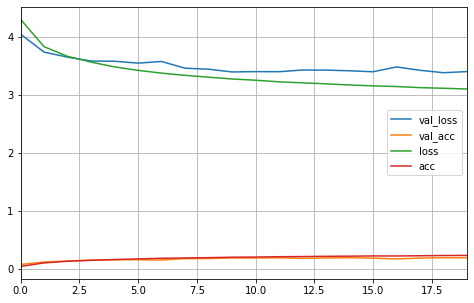

CPU times: user 1min 40s, sys: 12.5 s, total: 1min 53s
Wall time: 1min 3s


In [26]:
%%time
# Do the same for CIFAR-100.
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(3072,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(100, activation='softmax'))
model.compile(loss='categorical_crossentropy',
              optimizer=SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True),
              metrics=['accuracy'])

# Notice that you can reshape the data for an MLP inside the fit call without changing it globally!
history = model.fit(x_train_100.reshape(50000, 3072), y_train_100, epochs=20, batch_size=64, validation_data=(x_test_100.reshape(10000, 3072), y_test_100))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Train on 50000 samples, validate on 10000 samples
Epoch 1/10
50000/50000 [==============================] - 142s 3ms/step - loss: 1.5357 - acc: 0.4563 - val_loss: 1.4032 - val_acc: 0.4929
Epoch 2/10
50000/50000 [==============================] - 141s 3ms/step - loss: 1.2038 - acc: 0.5886 - val_loss: 1.2781 - val_acc: 0.5726
Epoch 3/10
50000/50000 [==============================] - 141s 3ms/step - loss: 1.1365 - acc: 0.6092 - val_loss: 1.1143 - val_acc: 0.6229
Epoch 4/10
50000/50000 [==============================] - 141s 3ms/step - loss: 1.0887 - acc: 0.6280 - val_loss: 1.2112 - val_acc: 0.5728
Epoch 5/10
50000/50000 [==============================] - 142s 3ms/step - loss: 1.0498 - acc: 0.6382 - val_loss: 1.3182 - val_acc: 0.5442
Epoch 6/10
50000/50000 [==============================] - 142s 3ms/step - loss: 1.0257 - acc: 0.6479 - val_loss: 1.0897 - val_acc: 0.6320
Epoch 7/10
50000/50000 [==============================] - 142s 3ms/step - loss: 0.9982 - acc: 0.6573 - val_loss: 1.0452 - 

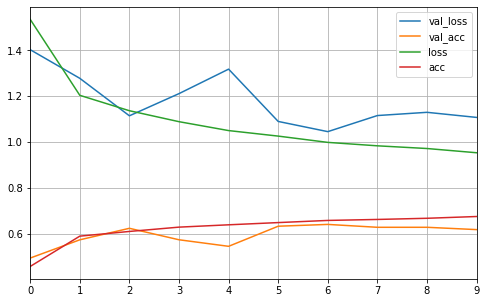

CPU times: user 54min 32s, sys: 15min 25s, total: 1h 9min 58s
Wall time: 23min 40s


In [27]:
%%time
# Create the CIFAR-10 CNN baseline here.
inputs = Input(shape=x_train.shape[1:])
output = Conv2D(32, (3, 3), padding='same', input_shape=x_train.shape[1:])(inputs)
output = Conv2D(32, (3, 3))(output)
output = MaxPooling2D(pool_size=(2, 2))(output)
output = Conv2D(32, (3, 3), padding='same')(output)
output = Conv2D(32, (3, 3))(output)
output = MaxPooling2D(pool_size=(2, 2))(output)
output = Flatten()(output)
output = Dense(512)(output)
output = Dropout(0.5)(output)

predictions = Dense(10, activation='softmax')(output)
model = Model(inputs=inputs, outputs=predictions)
model.compile(optimizer=SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True),
              loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Train on 50000 samples, validate on 10000 samples
Epoch 1/10
50000/50000 [==============================] - 152s 3ms/step - loss: 3.8754 - acc: 0.1220 - val_loss: 3.4063 - val_acc: 0.2069
Epoch 2/10
50000/50000 [==============================] - 151s 3ms/step - loss: 3.2044 - acc: 0.2407 - val_loss: 3.1347 - val_acc: 0.2686
Epoch 3/10
50000/50000 [==============================] - 151s 3ms/step - loss: 2.9165 - acc: 0.2949 - val_loss: 2.9001 - val_acc: 0.3051
Epoch 4/10
50000/50000 [==============================] - 151s 3ms/step - loss: 2.7701 - acc: 0.3262 - val_loss: 2.8032 - val_acc: 0.3167
Epoch 5/10
50000/50000 [==============================] - 151s 3ms/step - loss: 2.6755 - acc: 0.3443 - val_loss: 2.8017 - val_acc: 0.3260
Epoch 6/10
50000/50000 [==============================] - 152s 3ms/step - loss: 2.5922 - acc: 0.3591 - val_loss: 2.8048 - val_acc: 0.3208
Epoch 7/10
50000/50000 [==============================] - 152s 3ms/step - loss: 2.5315 - acc: 0.3733 - val_loss: 2.9018 - 

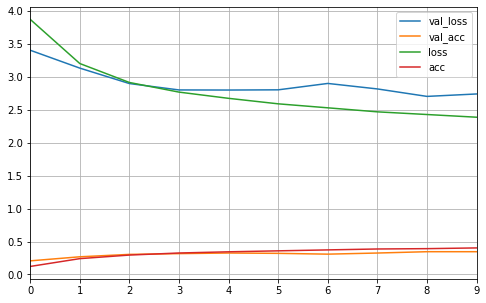

CPU times: user 56min 4s, sys: 18min 54s, total: 1h 14min 58s
Wall time: 25min 21s


In [28]:
%%time
# Create the CIFAR-100 CNN baseline here.
inputs = Input(shape=x_train_100.shape[1:])
output = Conv2D(32, (3, 3), padding='same', input_shape=x_train_100.shape[1:])(inputs)
output = Conv2D(32, (3, 3))(output)
output = MaxPooling2D(pool_size=(2, 2))(output)
output = Conv2D(32, (3, 3), padding='same')(output)
output = Conv2D(32, (3, 3))(output)
output = MaxPooling2D(pool_size=(2, 2))(output)
output = Flatten()(output)
output = Dense(512)(output)
output = Dropout(0.5)(output)

predictions = Dense(100, activation='softmax')(output)
model = Model(inputs=inputs, outputs=predictions)
model.compile(optimizer=SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True),
              loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train_100, y_train_100, epochs=10, batch_size=64, validation_data=(x_test_100, y_test_100))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Train on 50000 samples, validate on 10000 samples
Epoch 1/10
50000/50000 [==============================] - 338s 7ms/step - loss: 1.5045 - acc: 0.4706 - val_loss: 1.4664 - val_acc: 0.4940
Epoch 2/10
50000/50000 [==============================] - 336s 7ms/step - loss: 1.1706 - acc: 0.5978 - val_loss: 1.2404 - val_acc: 0.5832
Epoch 3/10
50000/50000 [==============================] - 338s 7ms/step - loss: 1.0887 - acc: 0.6274 - val_loss: 1.3081 - val_acc: 0.5752
Epoch 4/10
50000/50000 [==============================] - 337s 7ms/step - loss: 1.0303 - acc: 0.6488 - val_loss: 1.2408 - val_acc: 0.5843
Epoch 5/10
50000/50000 [==============================] - 339s 7ms/step - loss: 0.9834 - acc: 0.6612 - val_loss: 1.0581 - val_acc: 0.6495
Epoch 6/10
50000/50000 [==============================] - 337s 7ms/step - loss: 0.9457 - acc: 0.6749 - val_loss: 1.0412 - val_acc: 0.6465
Epoch 7/10
50000/50000 [==============================] - 338s 7ms/step - loss: 0.9112 - acc: 0.6879 - val_loss: 1.0646 - 

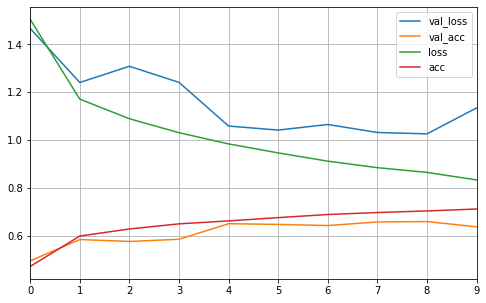

CPU times: user 2h 38min 28s, sys: 26min 31s, total: 3h 4min 59s
Wall time: 56min 19s


In [29]:
%%time
# Change the Convolutional layers to 64 filters for CIFAR-10.
inputs = Input(shape=x_train.shape[1:])
output = Conv2D(64, (3, 3), padding='same', input_shape=x_train.shape[1:])(inputs)
output = Conv2D(64, (3, 3))(output)
output = MaxPooling2D(pool_size=(2, 2))(output)
output = Conv2D(64, (3, 3), padding='same')(output)
output = Conv2D(64, (3, 3))(output)
output = MaxPooling2D(pool_size=(2, 2))(output)
output = Flatten()(output)
output = Dense(512)(output)
output = Dropout(0.5)(output)

predictions = Dense(10, activation='softmax')(output)
model = Model(inputs=inputs, outputs=predictions)
model.compile(optimizer=SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True),
              loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Train on 50000 samples, validate on 10000 samples
Epoch 1/10
50000/50000 [==============================] - 78s 2ms/step - loss: 1.6024 - acc: 0.4289 - val_loss: 1.2739 - val_acc: 0.5625
Epoch 2/10
50000/50000 [==============================] - 77s 2ms/step - loss: 1.2712 - acc: 0.5635 - val_loss: 1.2358 - val_acc: 0.5680
Epoch 3/10
50000/50000 [==============================] - 77s 2ms/step - loss: 1.2041 - acc: 0.5850 - val_loss: 1.1534 - val_acc: 0.6031
Epoch 4/10
50000/50000 [==============================] - 78s 2ms/step - loss: 1.1584 - acc: 0.6035 - val_loss: 1.1308 - val_acc: 0.6086
Epoch 5/10
50000/50000 [==============================] - 77s 2ms/step - loss: 1.1302 - acc: 0.6122 - val_loss: 1.4770 - val_acc: 0.5259
Epoch 6/10
50000/50000 [==============================] - 77s 2ms/step - loss: 1.1186 - acc: 0.6159 - val_loss: 1.1646 - val_acc: 0.5954
Epoch 7/10
50000/50000 [==============================] - 78s 2ms/step - loss: 1.1006 - acc: 0.6216 - val_loss: 1.2173 - val_acc

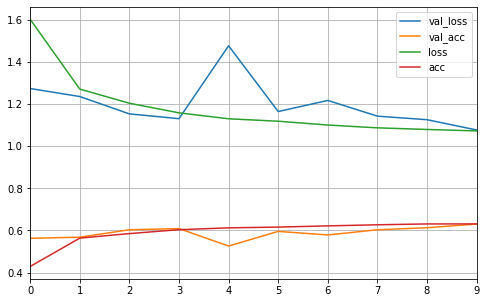

CPU times: user 25min 13s, sys: 9min 32s, total: 34min 45s
Wall time: 12min 57s


In [30]:
%%time
# Change the Convolutional layers to 16 filters for CIFAR-10.
inputs = Input(shape=x_train.shape[1:])
output = Conv2D(16, (3, 3), padding='same', input_shape=x_train.shape[1:])(inputs)
output = Conv2D(16, (3, 3))(output)
output = MaxPooling2D(pool_size=(2, 2))(output)
output = Conv2D(16, (3, 3), padding='same')(output)
output = Conv2D(16, (3, 3))(output)
output = MaxPooling2D(pool_size=(2, 2))(output)
output = Flatten()(output)
output = Dense(512)(output)
output = Dropout(0.5)(output)

predictions = Dense(10, activation='softmax')(output)
model = Model(inputs=inputs, outputs=predictions)
model.compile(optimizer=SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True),
              loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Train on 50000 samples, validate on 10000 samples
Epoch 1/10
50000/50000 [==============================] - 302s 6ms/step - loss: 14.4355 - acc: 0.1001 - val_loss: 14.5063 - val_acc: 0.1000
Epoch 2/10
50000/50000 [==============================] - 306s 6ms/step - loss: 14.5063 - acc: 0.1000 - val_loss: 14.5063 - val_acc: 0.1000
Epoch 3/10
50000/50000 [==============================] - 306s 6ms/step - loss: 14.5063 - acc: 0.1000 - val_loss: 14.5063 - val_acc: 0.1000
Epoch 4/10
50000/50000 [==============================] - 312s 6ms/step - loss: 14.5063 - acc: 0.1000 - val_loss: 14.5063 - val_acc: 0.1000
Epoch 5/10
50000/50000 [==============================] - 307s 6ms/step - loss: 14.5063 - acc: 0.1000 - val_loss: 14.5063 - val_acc: 0.1000
Epoch 6/10
50000/50000 [==============================] - 306s 6ms/step - loss: 14.5063 - acc: 0.1000 - val_loss: 14.5063 - val_acc: 0.1000
Epoch 7/10
50000/50000 [==============================] - 307s 6ms/step - loss: 14.5063 - acc: 0.1000 - val_lo

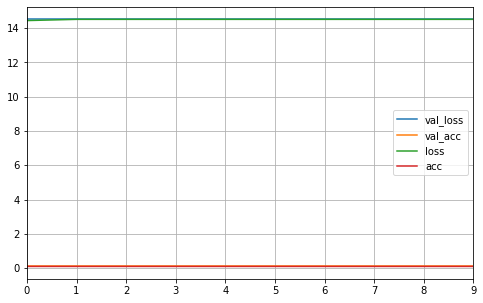

CPU times: user 2h 12min 28s, sys: 26min 41s, total: 2h 39min 10s
Wall time: 51min 5s


In [32]:
%%time
# Remove the Max Pooling Layers for CIFAR-10.
inputs = Input(shape=x_train.shape[1:])
output = Conv2D(32, (3, 3), padding='same', input_shape=x_train.shape[1:])(inputs)
output = Conv2D(32, (3, 3))(output)
#output = MaxPooling2D(pool_size=(2, 2))(output)
output = Conv2D(32, (3, 3), padding='same')(output)
output = Conv2D(32, (3, 3))(output)
#output = MaxPooling2D(pool_size=(2, 2))(output)
output = Flatten()(output)
output = Dense(512)(output)
#output = Dropout(0.5)(output)

predictions = Dense(10, activation='softmax')(output)
model = Model(inputs=inputs, outputs=predictions)
model.compile(optimizer=SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True),
              loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Train on 50000 samples, validate on 10000 samples
Epoch 1/10
50000/50000 [==============================] - 311s 6ms/step - loss: 15.1685 - acc: 0.0112 - val_loss: 15.9569 - val_acc: 0.0100
Epoch 2/10
50000/50000 [==============================] - 309s 6ms/step - loss: 15.9569 - acc: 0.0100 - val_loss: 15.9569 - val_acc: 0.0100
Epoch 3/10
50000/50000 [==============================] - 308s 6ms/step - loss: 15.9569 - acc: 0.0100 - val_loss: 15.9569 - val_acc: 0.0100
Epoch 4/10
50000/50000 [==============================] - 308s 6ms/step - loss: 15.9569 - acc: 0.0100 - val_loss: 15.9569 - val_acc: 0.0100
Epoch 5/10
50000/50000 [==============================] - 309s 6ms/step - loss: 15.9569 - acc: 0.0100 - val_loss: 15.9569 - val_acc: 0.0100
Epoch 6/10
50000/50000 [==============================] - 310s 6ms/step - loss: 15.9569 - acc: 0.0100 - val_loss: 15.9569 - val_acc: 0.0100
Epoch 7/10
50000/50000 [==============================] - 309s 6ms/step - loss: 15.9569 - acc: 0.0100 - val_lo

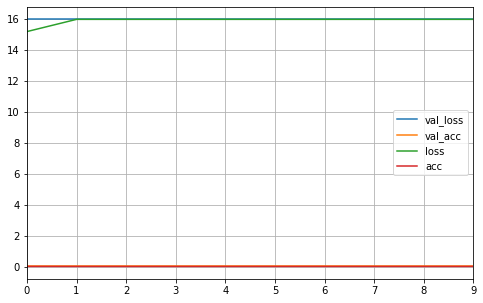

CPU times: user 2h 13min 8s, sys: 27min 44s, total: 2h 40min 52s
Wall time: 51min 36s


In [33]:
%%time
# Remove the Max Pooling Layers for CIFAR-100.
inputs = Input(shape=x_train.shape[1:])
output = Conv2D(32, (3, 3), padding='same', input_shape=x_train.shape[1:])(inputs)
output = Conv2D(32, (3, 3))(output)
#output = MaxPooling2D(pool_size=(2, 2))(output)
output = Conv2D(32, (3, 3), padding='same')(output)
output = Conv2D(32, (3, 3))(output)
#output = MaxPooling2D(pool_size=(2, 2))(output)
output = Flatten()(output)
output = Dense(512)(output)
#output = Dropout(0.5)(output)

predictions = Dense(100, activation='softmax')(output)
model = Model(inputs=inputs, outputs=predictions)
model.compile(optimizer=SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True),
              loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train_100, y_train_100, epochs=10, batch_size=64, validation_data=(x_test_100, y_test_100))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

In [34]:
# Data Augmentation.
batch_size = 64
num_classes = 10
epochs = 40
data_augmentation = True

model = Sequential()
model.add(Conv2D(32, (3, 3), padding='same', input_shape=x_train.shape[1:]))
model.add(Activation('relu'))
model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes))
model.add(Activation('softmax'))

opt = SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True)

model.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

if not data_augmentation:
    print('Not using data augmentation.')
    model.fit(x_train, y_train,
              batch_size=batch_size,
              epochs=epochs,
              validation_data=(x_test, y_test),
              shuffle=True)
else:
    print('Using real-time data augmentation.')
    datagen = ImageDataGenerator(
        featurewise_center=False,
        samplewise_center=False,
        featurewise_std_normalization=False,
        samplewise_std_normalization=False,
        zca_whitening=False,
        zca_epsilon=1e-06,
        rotation_range=0,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0., 
        zoom_range=0., 
        channel_shift_range=0.,
        fill_mode='nearest',
        cval=0., 
        horizontal_flip=True,
        vertical_flip=False, 
        rescale=None,
        preprocessing_function=None,
        data_format=None,
        validation_split=0.0)

    datagen.fit(x_train)

    model.fit(datagen.flow(x_train, y_train,
                        batch_size=batch_size),
                        epochs=epochs,
                        validation_data=(x_test, y_test))

scores = model.evaluate(x_test, y_test, verbose=0)

Using real-time data augmentation.
Epoch 1/40
782/782 [==============================] - 160s 205ms/step - loss: 1.9361 - acc: 0.2871 - val_loss: 1.5542 - val_acc: 0.4397
Epoch 2/40
782/782 [==============================] - 155s 198ms/step - loss: 1.5143 - acc: 0.4487 - val_loss: 1.3200 - val_acc: 0.5192
Epoch 3/40
782/782 [==============================] - 156s 199ms/step - loss: 1.3593 - acc: 0.5073 - val_loss: 1.1249 - val_acc: 0.5981
Epoch 4/40
782/782 [==============================] - 155s 198ms/step - loss: 1.2341 - acc: 0.5566 - val_loss: 1.1549 - val_acc: 0.5844
Epoch 5/40
782/782 [==============================] - 155s 198ms/step - loss: 1.1503 - acc: 0.5904 - val_loss: 0.9860 - val_acc: 0.6542
Epoch 6/40
782/782 [==============================] - 155s 198ms/step - loss: 1.0824 - acc: 0.6167 - val_loss: 0.9989 - val_acc: 0.6501
Epoch 7/40
782/782 [==============================] - 156s 199ms/step - loss: 1.0263 - acc: 0.6377 - val_loss: 0.8840 - val_acc: 0.6927
Epoch 8/40
78

In [35]:
scores

[0.6038028013706207, 0.802]

In [ ]:
# Here is our CIFAR-10 CNN ResNet.
inputs = tf.keras.Input(shape=(32, 32, 3), name='img')
x = Conv2D(32, 3, activation='relu')(inputs)
x = Conv2D(64, 3, activation='relu')(x)
block_1_output = MaxPooling2D(3)(x)

x = Conv2D(64, 3, activation='relu', padding='same')(block_1_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_2_output = tf.keras.layers.add([x, block_1_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_2_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_3_output = tf.keras.layers.add([x, block_2_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_3_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_4_output = tf.keras.layers.add([x, block_3_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_4_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_5_output = tf.keras.layers.add([x, block_4_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_5_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_6_output = tf.keras.layers.add([x, block_5_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_6_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_7_output = tf.keras.layers.add([x, block_6_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_7_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_8_output = tf.keras.layers.add([x, block_7_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_8_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_9_output = tf.keras.layers.add([x, block_8_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_9_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_10_output = tf.keras.layers.add([x, block_9_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_10_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_11_output = tf.keras.layers.add([x, block_10_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_11_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_12_output = tf.keras.layers.add([x, block_11_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_12_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_13_output = tf.keras.layers.add([x, block_12_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_13_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_14_output = tf.keras.layers.add([x, block_13_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_14_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_15_output = tf.keras.layers.add([x, block_14_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_15_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_16_output = tf.keras.layers.add([x, block_15_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_16_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_17_output = tf.keras.layers.add([x, block_16_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_17_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_18_output = tf.keras.layers.add([x, block_17_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_18_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_19_output = tf.keras.layers.add([x, block_18_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_19_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_20_output = tf.keras.layers.add([x, block_19_output])

x = Conv2D(64, 3, activation='relu')(block_20_output)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='resnet')


model.compile(Adam(amsgrad=True), 'binary_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train,
          batch_size=256,
          epochs=10,
          validation_split=0.2)

In [37]:
%%time
# Create the CIFAR-100 CNN ResNet.
inputs = tf.keras.Input(shape=(32, 32, 3), name='img')
x = Conv2D(32, 3, activation='relu')(inputs)
x = Conv2D(64, 3, activation='relu')(x)
block_1_output = MaxPooling2D(3)(x)

x = Conv2D(64, 3, activation='relu', padding='same')(block_1_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_2_output = tf.keras.layers.add([x, block_1_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_2_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_3_output = tf.keras.layers.add([x, block_2_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_3_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_4_output = tf.keras.layers.add([x, block_3_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_4_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_5_output = tf.keras.layers.add([x, block_4_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_5_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_6_output = tf.keras.layers.add([x, block_5_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_6_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_7_output = tf.keras.layers.add([x, block_6_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_7_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_8_output = tf.keras.layers.add([x, block_7_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_8_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_9_output = tf.keras.layers.add([x, block_8_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_9_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_10_output = tf.keras.layers.add([x, block_9_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_10_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_11_output = tf.keras.layers.add([x, block_10_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_11_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_12_output = tf.keras.layers.add([x, block_11_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_12_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_13_output = tf.keras.layers.add([x, block_12_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_13_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_14_output = tf.keras.layers.add([x, block_13_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_14_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_15_output = tf.keras.layers.add([x, block_14_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_15_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_16_output = tf.keras.layers.add([x, block_15_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_16_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_17_output = tf.keras.layers.add([x, block_16_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_17_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_18_output = tf.keras.layers.add([x, block_17_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_18_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_19_output = tf.keras.layers.add([x, block_18_output])

x = Conv2D(64, 3, activation='relu', padding='same')(block_19_output)
x = BatchNormalization()(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
block_20_output = tf.keras.layers.add([x, block_19_output])

x = Conv2D(64, 3, activation='relu')(block_20_output)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(100, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='resnet')

model.compile(Adam(amsgrad=True), 'binary_crossentropy', metrics=['accuracy'])
model.fit(x_train_100, y_train_100, batch_size=256, epochs=10, validation_data=(x_test_100, y_test_100))

Train on 50000 samples, validate on 10000 samples
Epoch 1/10
50000/50000 [==============================] - 973s 19ms/step - loss: 0.0543 - acc: 0.9900 - val_loss: 0.0595 - val_acc: 0.9900
Epoch 2/10
50000/50000 [==============================] - 931s 19ms/step - loss: 0.0487 - acc: 0.9900 - val_loss: 0.0507 - val_acc: 0.9900
Epoch 3/10
50000/50000 [==============================] - 929s 19ms/step - loss: 0.0450 - acc: 0.9900 - val_loss: 0.0448 - val_acc: 0.9900
Epoch 4/10
50000/50000 [==============================] - 928s 19ms/step - loss: 0.0417 - acc: 0.9902 - val_loss: 0.0421 - val_acc: 0.9902
Epoch 5/10
50000/50000 [==============================] - 906s 18ms/step - loss: 0.0391 - acc: 0.9904 - val_loss: 0.0385 - val_acc: 0.9905
Epoch 6/10
50000/50000 [==============================] - 928s 19ms/step - loss: 0.0370 - acc: 0.9906 - val_loss: 0.0420 - val_acc: 0.9903
Epoch 7/10
50000/50000 [==============================] - 933s 19ms/step - loss: 0.0349 - acc: 0.9908 - val_loss: 0.

In [43]:
# Create your own CNN that rivals a CNN ResNet for CIFAR-100.
inputs = tf.keras.Input(shape=(32, 32, 3), name='img')
x = Conv2D(128, 3, activation='relu')(inputs)
x = Conv2D(128, 3, activation='relu')(x)
block_output = MaxPooling2D(3)(x)

num_layers = 19
for i in range(num_layers):
    x = Conv2D(128, 3, activation='relu', padding='same')(block_output)
    x = BatchNormalization()(x)
    x = Conv2D(128, 3, activation='relu', padding='same')(x)
    block_output = tf.keras.layers.add([x, block_output])
    
num_dense_neurons = 200
x = Conv2D(128, 3, activation='relu')(block_output)
x = GlobalAveragePooling2D()(x)
x = Dense(num_dense_neurons, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(100, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='customized_resnet')

history = model.compile(Adam(amsgrad=True), 'binary_crossentropy', metrics=['accuracy'])
model.fit(x_train_100, y_train_100, batch_size=256, epochs=10, validation_data=(x_test_100, y_test_100))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Train on 50000 samples, validate on 10000 samples
Epoch 1/10
  256/50000 [..............................] - ETA: 1:25:52 - loss: 0.1143 - acc: 0.9859

KeyboardInterrupt: 